## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})

CHARTS = os.path.join(os.getcwd(), '..', 'charts')
os.makedirs(CHARTS, exist_ok=True)

def save(name):
    plt.savefig(os.path.join(CHARTS, name), bbox_inches='tight')
    plt.show()

df = pd.read_parquet(os.path.join(os.getcwd(), '..', 'data', 'cleaned_flight_data_Q1_2024.parquet'))
print(f'{len(df):,} rows loaded')

1,625,081 rows loaded


## GENERAL EDA

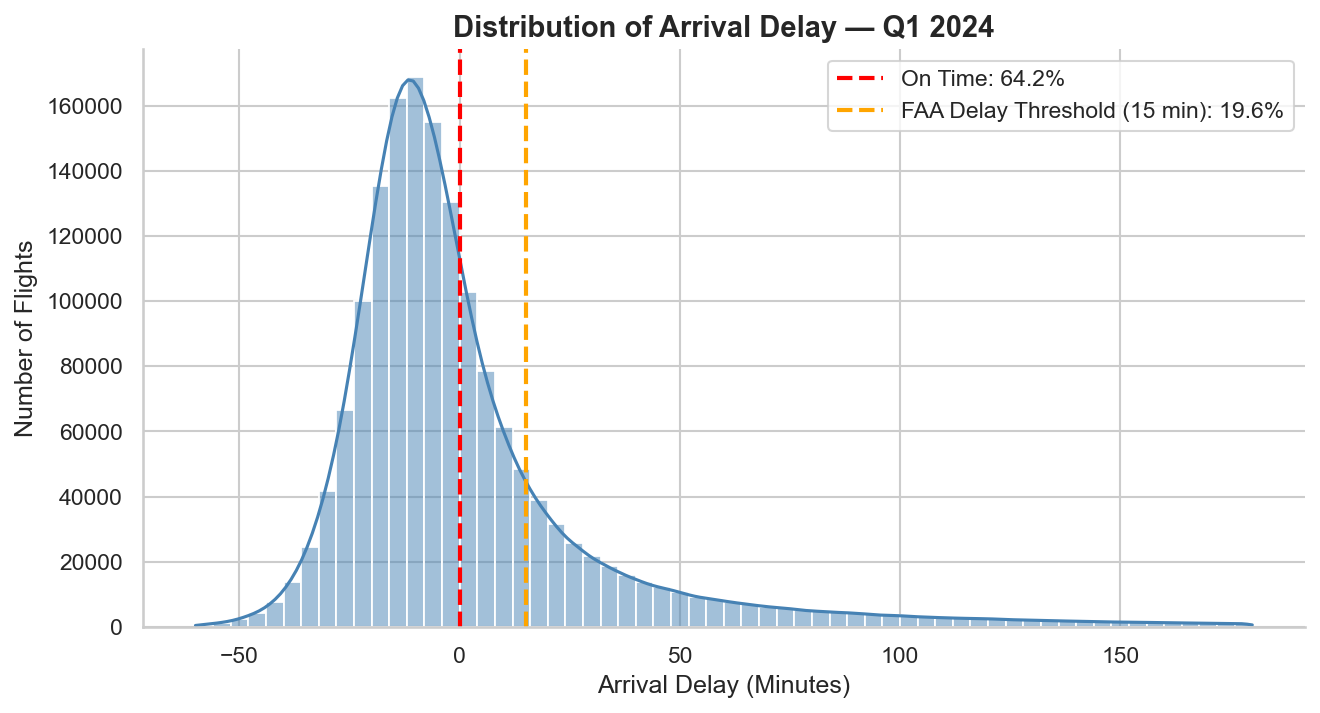

In [2]:
# Arrival Delay Distribution
subset = df[df['ArrDelay'].between(-60, 180)]

plt.figure(figsize=(10, 5))
sns.histplot(subset['ArrDelay'], bins=60, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', lw=2, label=f'On Time: {(df["ArrDelay"] <= 0).mean() * 100:.1f}%')
plt.axvline(15, color='orange', linestyle='--', lw=2, label=f'FAA Delay Threshold (15 min): {(df["ArrDelay"] > 15).mean() * 100:.1f}%')
plt.title('Distribution of Arrival Delay — Q1 2024', fontsize=14, fontweight='bold')
plt.xlabel('Arrival Delay (Minutes)')
plt.ylabel('Number of Flights')
plt.legend()
save('arrival_delay_dist.png')


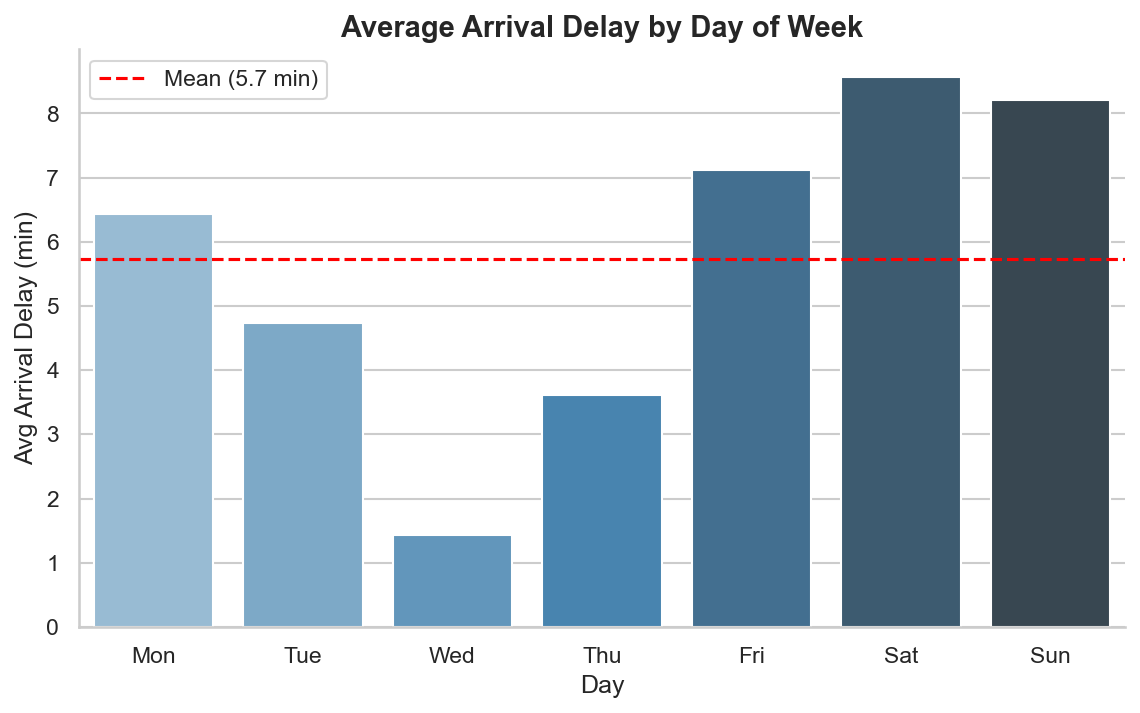

In [3]:
# Average Arrival Delay by Day of Week
day_names = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
day_delay = df.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()
day_delay['Day'] = day_delay['DayOfWeek'].map(day_names)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=day_delay, x='Day', y='ArrDelay', order=list(day_names.values()), palette='Blues_d', hue='Day', legend=False)
plt.axhline(df['ArrDelay'].mean(), color='red', linestyle='--', lw=1.5, label=f"Mean ({df['ArrDelay'].mean():.1f} min)")

plt.title('Average Arrival Delay by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Avg Arrival Delay (min)')
plt.legend()
save('delay_by_dow.png')

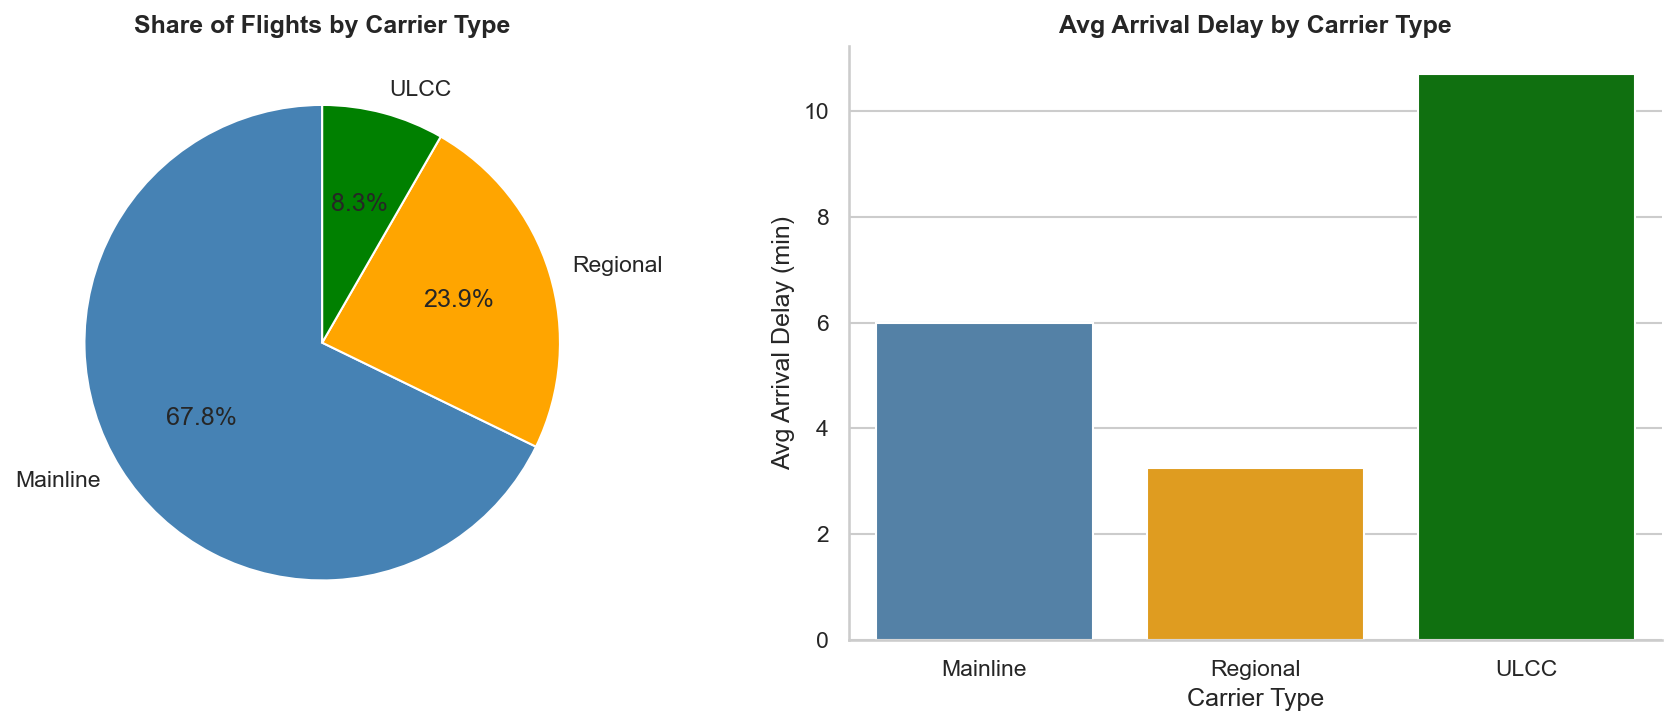

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

carrier_order = ['Mainline', 'Regional', 'ULCC']
carrier_palette = {'Mainline': 'steelblue', 'Regional': 'orange', 'ULCC': 'green'}

# Left: flight volume
ct_counts = df['Carrier_Type'].value_counts()
axes[0].pie(ct_counts, labels=ct_counts.index, colors =list(carrier_palette.values()), autopct='%1.1f%%', startangle=90)
axes[0].set_title('Share of Flights by Carrier Type', fontweight='bold')

# Right: avg arrival delay
sns.barplot(data=df, x='Carrier_Type', y='ArrDelay', order=carrier_order, palette=carrier_palette, hue='Carrier_Type', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('Avg Arrival Delay by Carrier Type', fontweight='bold')
axes[1].set_xlabel('Carrier Type')
axes[1].set_ylabel('Avg Arrival Delay (min)')

plt.tight_layout()
save('carrier_breakdown.png')